In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Todo funcionando")

Todo funcionando


In [2]:
precio = 100.0
numeros = np.array([10, 20, 30, 40, 50])
print(numeros)
print(np.mean(numeros))




[10 20 30 40 50]
30.0


In [3]:
precios = np.array([1800, 1850, 1920, 1875, 1910, 1955, 1890])
print(precios)
print(np.mean(precios))
print(np.min(precios))
print(np.max(precios))


[1800 1850 1920 1875 1910 1955 1890]
1885.7142857142858
1800
1955


In [4]:
print(precios[0])    # primer precio
print(precios[-1])   # último precio
print(precios[2])    # tercer precio
print(precios[-2])   # segundo desde atrás


1800
1890
1920
1955


In [5]:
print(precios[1:4])   # del segundo al cuarto
print(precios[:3])    # primeros 3
print(precios[-3:])   # últimos 3

[1850 1920 1875]
[1800 1850 1920]
[1910 1955 1890]


In [6]:
# Operaciones básicas sobre el array completo
print(precios + 100)      # sumarle 100 a cada precio
print(precios * 2)        # multiplicar cada precio por 2
print(precios - precios.mean())  # restarle el promedio a cada valor

[1900 1950 2020 1975 2010 2055 1990]
[3600 3700 3840 3750 3820 3910 3780]
[-85.71428571 -35.71428571  34.28571429 -10.71428571  24.28571429
  69.28571429   4.28571429]


In [7]:
# Array 2D — una tabla de 3 días con 3 datos cada uno
# columnas: precio_apertura, precio_cierre, volumen
datos = np.array([
    [1800, 1850, 320],
    [1850, 1920, 415],
    [1920, 1875, 290]
])

print(datos)
print("Forma:", datos.shape)
print("Filas:", datos.shape[0])
print("Columnas:", datos.shape[1])

[[1800 1850  320]
 [1850 1920  415]
 [1920 1875  290]]
Forma: (3, 3)
Filas: 3
Columnas: 3


In [8]:
print(datos[1, 1])   # fila 1, columna 1
print(datos[0, 0])   # fila 0, columna 0
print(datos[2, 2])   # fila 2, columna 2


1920
1800
290


In [9]:
import pandas as pd

# Tu primer DataFrame — una tabla real
df = pd.DataFrame({
    'dia':     [1, 2, 3, 4, 5],
    'precio':  [1800, 1850, 1920, 1875, 1910],
    'volumen': [320, 415, 290, 380, 445]
})

print(df)

   dia  precio  volumen
0    1    1800      320
1    2    1850      415
2    3    1920      290
3    4    1875      380
4    5    1910      445


In [10]:
print(df.head(3))     # primeras 3 filas
print(df.shape)       # dimensiones de la tabla
print(df.describe())  # estadísticas automáticas

   dia  precio  volumen
0    1    1800      320
1    2    1850      415
2    3    1920      290
(5, 3)
            dia       precio    volumen
count  5.000000     5.000000    5.00000
mean   3.000000  1871.000000  370.00000
std    1.581139    48.528342   64.51744
min    1.000000  1800.000000  290.00000
25%    2.000000  1850.000000  320.00000
50%    3.000000  1875.000000  380.00000
75%    4.000000  1910.000000  415.00000
max    5.000000  1920.000000  445.00000


In [11]:
import pandas as pd

url = "https://query1.finance.yahoo.com/v7/finance/download/GC=F?period1=1420070400&period2=1719792000&interval=1d"
df_oro = pd.read_csv(url)
print(df_oro.head())
print(df_oro.shape)

HTTPError: HTTP Error 429: Too Many Requests

In [ ]:
import yfinance as yf

# Descargar precios reales del oro 2020-2024
df_oro = yf.download("GC=F", start="2020-01-01", end="2024-12-31")

print(df_oro.head())
print(df_oro.shape)

In [ ]:
# Análisis exploratorio del oro
print("=== FORMA DEL DATASET ===")
print(df_oro.shape)

print("\n=== PRIMERAS FILAS ===")
print(df_oro.head())

print("\n=== ESTADÍSTICAS ===")
print(df_oro.describe())

print("\n=== DATOS FALTANTES ===")
print(df_oro.isnull().sum())

In [ ]:
import matplotlib.pyplot as plt

# Gráfico del precio de cierre del oro 2020-2024
plt.figure(figsize=(12, 5))
plt.plot(df_oro['Close'], color='gold', linewidth=1)
plt.title('Precio del Oro 2020-2024')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Volumen y retornos diarios
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Gráfico 1 — Precio de cierre
df_oro['Close'].plot(ax=axes[0], color='gold', linewidth=1)
axes[0].set_title('Precio del Oro 2020-2024')
axes[0].set_ylabel('Precio (USD)')
axes[0].grid(True, alpha=0.3)

# Gráfico 2 — Retorno diario
df_oro['retorno'] = df_oro['Close'].pct_change() * 100
df_oro['retorno'].plot(ax=axes[1], color='blue', linewidth=0.8)
axes[1].set_title('Retorno Diario (%)')
axes[1].set_ylabel('Retorno (%)')
axes[1].axhline(y=0, color='red', linewidth=1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Retorno promedio diario:", df_oro['retorno'].mean().round(4), "%")
print("Volatilidad diaria:", df_oro['retorno'].std().round(4), "%")
print("Peor día:", df_oro['retorno'].min().round(4), "%")
print("Mejor día:", df_oro['retorno'].max().round(4), "%")

In [ ]:
# Histograma de retornos — ver la distribución
plt.figure(figsize=(10, 5))
df_oro['retorno'].hist(bins=80, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(x=0, color='red', linewidth=2, label='Cero')
plt.axvline(x=df_oro['retorno'].mean(), color='green', 
            linewidth=2, label=f'Promedio: {df_oro["retorno"].mean():.3f}%')
plt.title('Distribución de Retornos Diarios del Oro 2020-2024')
plt.xlabel('Retorno Diario (%)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Calcular correlaciones entre todas las columnas
correlaciones = df_oro.corr()
print(correlaciones)



In [12]:
correlaciones = df_oro.corr()
print(correlaciones)



NameError: name 'df_oro' is not defined

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Descargar datos
df_oro = yf.download("GC=F", start="2020-01-01", end="2024-12-31")

# Agregar retorno
df_oro['retorno'] = df_oro['Close'].pct_change() * 100

# Confirmar que cargó
print("Filas:", df_oro.shape[0])
print("Columnas:", df_oro.columns.tolist())





[*********************100%***********************]  1 of 1 completed

Filas: 1257
Columnas: [('Close', 'GC=F'), ('High', 'GC=F'), ('Low', 'GC=F'), ('Open', 'GC=F'), ('Volume', 'GC=F'), ('retorno', '')]


In [15]:
correlaciones = df_oro.corr(numeric_only=True)
print(correlaciones)



Price              Close      High       Low      Open    Volume   retorno
Ticker              GC=F      GC=F      GC=F      GC=F      GC=F          
Price   Ticker                                                            
Close   GC=F    1.000000  0.998884  0.999209  0.997946 -0.012979  0.048161
High    GC=F    0.998884  1.000000  0.998395  0.999091 -0.016793  0.019530
Low     GC=F    0.999209  0.998395  1.000000  0.998750 -0.009484  0.024959
Open    GC=F    0.997946  0.999091  0.998750  1.000000 -0.013387 -0.007153
Volume  GC=F   -0.012979 -0.016793 -0.009484 -0.013387  1.000000 -0.029539
retorno         0.048161  0.019530  0.024959 -0.007153 -0.029539  1.000000


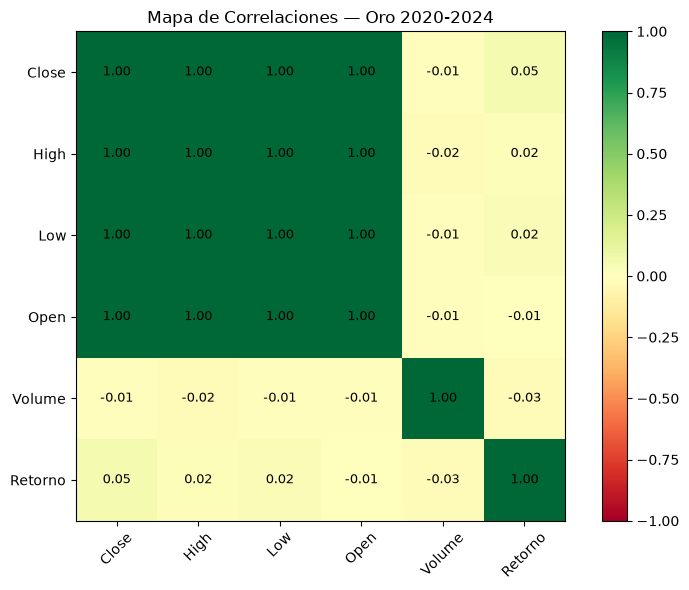

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

# Obtener valores numéricos
corr_values = correlaciones.values
labels = ['Close', 'High', 'Low', 'Open', 'Volume', 'Retorno']

# Mapa de calor manual
im = ax.imshow(corr_values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im)

# Etiquetas
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45)
ax.set_yticklabels(labels)

# Números dentro del mapa
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr_values[i,j]:.2f}',
                ha='center', va='center', fontsize=9)

ax.set_title('Mapa de Correlaciones — Oro 2020-2024')
plt.tight_layout()
plt.show()

In [17]:
# Crear features nuevas
df_oro['ma7']  = df_oro['Close'].rolling(7).mean()   # media móvil 7 días
df_oro['ma21'] = df_oro['Close'].rolling(21).mean()  # media móvil 21 días
df_oro['lag1'] = df_oro['Close'].shift(1)            # precio de ayer
df_oro['lag2'] = df_oro['Close'].shift(2)            # precio de anteayer

# Ver resultado
print(df_oro[['Close', 'ma7', 'ma21', 'lag1', 'lag2']].head(25))

Price             Close          ma7         ma21         lag1         lag2
Ticker             GC=F                                                    
Date                                                                       
2020-01-02  1524.500000          NaN          NaN          NaN          NaN
2020-01-03  1549.199951          NaN          NaN  1524.500000          NaN
2020-01-06  1566.199951          NaN          NaN  1549.199951  1524.500000
2020-01-07  1571.800049          NaN          NaN  1566.199951  1549.199951
2020-01-08  1557.400024          NaN          NaN  1571.800049  1566.199951
2020-01-09  1551.699951          NaN          NaN  1557.400024  1571.800049
2020-01-10  1557.500000  1554.042847          NaN  1551.699951  1557.400024
2020-01-13  1548.400024  1557.457136          NaN  1557.500000  1551.699951
2020-01-14  1542.400024  1556.485718          NaN  1548.400024  1557.500000
2020-01-15  1552.099976  1554.471436          NaN  1542.400024  1548.400024
2020-01-16  

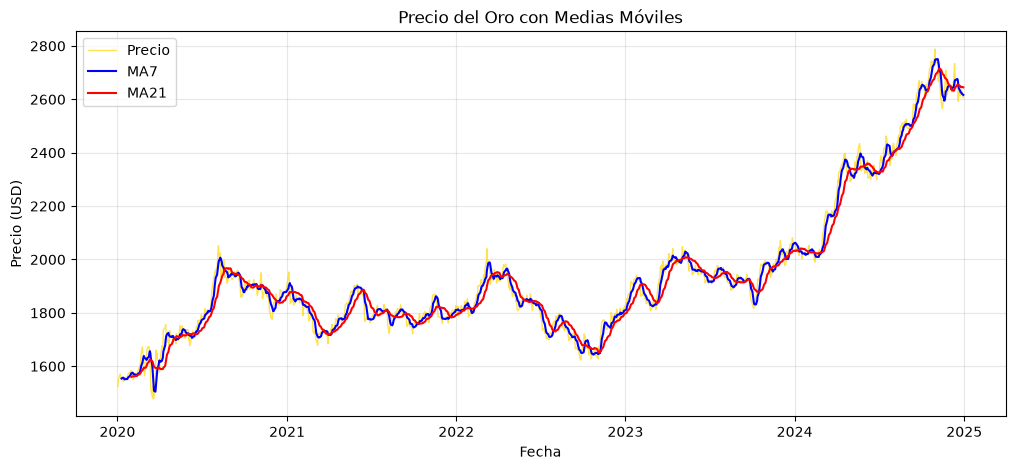

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(df_oro['Close'], color='gold', linewidth=1, label='Precio', alpha=0.7)
plt.plot(df_oro['ma7'],  color='blue',  linewidth=1.5, label='MA7')
plt.plot(df_oro['ma21'], color='red',   linewidth=1.5, label='MA21')
plt.title('Precio del Oro con Medias Móviles')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



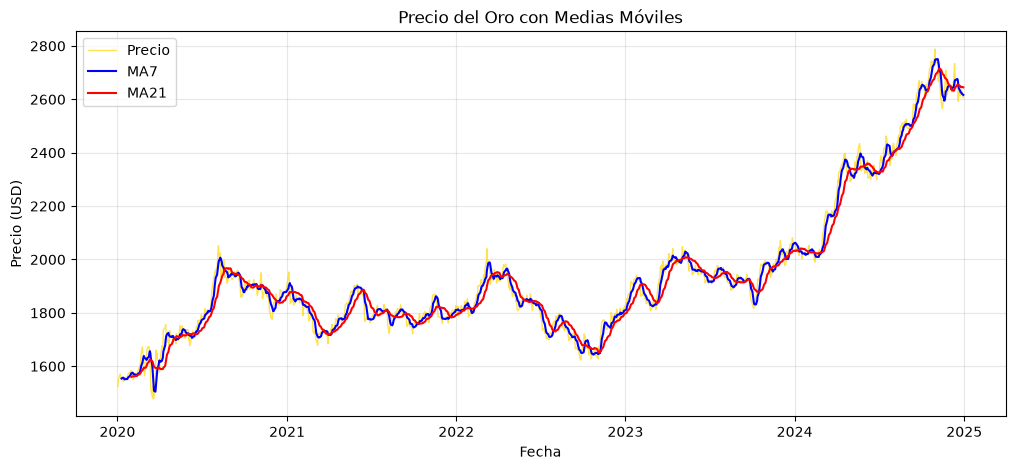

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(df_oro['Close'], color='gold', linewidth=1, label='Precio', alpha=0.7)
plt.plot(df_oro['ma7'],  color='blue',  linewidth=1.5, label='MA7')
plt.plot(df_oro['ma21'], color='red',   linewidth=1.5, label='MA21')
plt.title('Precio del Oro con Medias Móviles')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



KeyError: 'ma50'

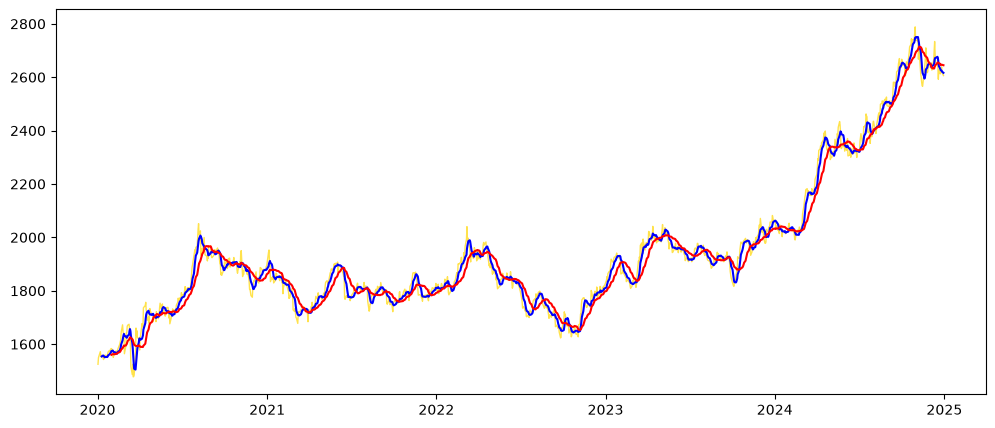

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(df_oro['Close'], color='gold', linewidth=1, label='Precio', alpha=0.7)
plt.plot(df_oro['ma7'],  color='blue',  linewidth=1.5, label='MA7')
plt.plot(df_oro['ma21'], color='red',   linewidth=1.5, label='MA21')
plt.plot(df_oro['ma50'],  color='green',  linewidth=1.5, label='MA50')
plt.plot(df_oro['ma200'], color='black',   linewidth=1.5, label='MA200')
plt.title('Precio del Oro con Medias Móviles')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
df_oro['ma50']  = df_oro['Close'].rolling(50).mean()
df_oro['ma200'] = df_oro['Close'].rolling(200).mean()


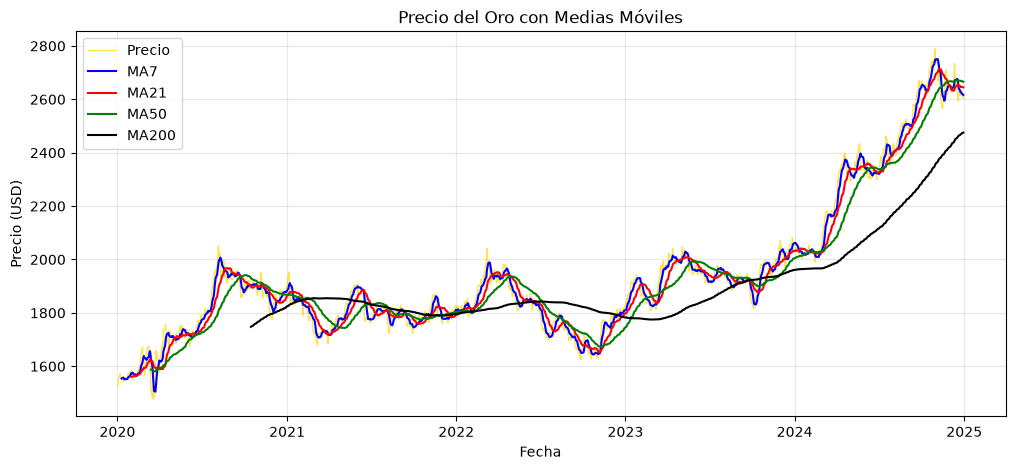

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(df_oro['Close'], color='gold', linewidth=1, label='Precio', alpha=0.7)
plt.plot(df_oro['ma7'],  color='blue',  linewidth=1.5, label='MA7')
plt.plot(df_oro['ma21'], color='red',   linewidth=1.5, label='MA21')
plt.plot(df_oro['ma50'],  color='green',  linewidth=1.5, label='MA50')
plt.plot(df_oro['ma200'], color='black',   linewidth=1.5, label='MA200')
plt.title('Precio del Oro con Medias Móviles')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()